In [2]:
import pandas as pd

df = pd.read_csv("or_optimization_dataset.csv")

print(df.head())
print(df.info())

   hadm_id procedure_type scheduled_start_time  scheduled_duration  \
0   142345     Orthopedic           2025-01-28                 162   
1   105331        General           2025-01-28                 239   
2   165520        Cardiac           2025-01-13                 152   
3   199207     Orthopedic           2025-01-09                  74   
4   177759     Orthopedic           2025-01-29                 166   

   actual_duration  emergency_flag  acuity_score or_room_id surgeon_id  \
0              183               1          16.9        OR2        DR2   
1              262               1          11.6        OR2        DR1   
2              155               1          18.5        OR1        DR2   
3               68               1          17.7        OR3        DR1   
4              204               1          10.3        OR3        DR1   

  equipment_id  
0          EQ3  
1          EQ1  
2          EQ4  
3          EQ4  
4          EQ2  
<class 'pandas.core.frame.DataFr

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [5]:
df= pd.read_csv("or_optimization_dataset.csv")
df

,hadm_id,procedure_type,scheduled_start_time,scheduled_duration,actual_duration,emergency_flag,acuity_score,or_room_id,surgeon_id,equipment_id
0,142345,Orthopedic,2025-01-28,162,183,1,16.9,OR2,DR2,EQ3
1,105331,General,2025-01-28,239,262,1,11.6,OR2,DR1,EQ1
2,165520,Cardiac,2025-01-13,152,155,1,18.5,OR1,DR2,EQ4
3,199207,Orthopedic,2025-01-09,74,68,1,17.7,OR3,DR1,EQ4
4,177759,Orthopedic,2025-01-29,166,204,1,10.3,OR3,DR1,EQ2
...,...,...,...,...,...,...,...,...,...,...
124,198330,Cardiac,2025-01-09,201,234,1,14.5,OR3,DR2,EQ3
125,174245,General,2025-01-30,162,197,1,60.5,OR3,DR2,EQ2
126,163189,Neuro,2025-01-05,86,98,1,20.3,OR2,DR3,EQ2
127,192189,Cardiac,2025-01-01,196,199,1,15.4,OR1,DR3,EQ2


In [6]:
df.head()

,hadm_id,procedure_type,scheduled_start_time,scheduled_duration,actual_duration,emergency_flag,acuity_score,or_room_id,surgeon_id,equipment_id
0,142345,Orthopedic,2025-01-28,162,183,1,16.9,OR2,DR2,EQ3
1,105331,General,2025-01-28,239,262,1,11.6,OR2,DR1,EQ1
2,165520,Cardiac,2025-01-13,152,155,1,18.5,OR1,DR2,EQ4
3,199207,Orthopedic,2025-01-09,74,68,1,17.7,OR3,DR1,EQ4
4,177759,Orthopedic,2025-01-29,166,204,1,10.3,OR3,DR1,EQ2


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129 entries, 0 to 128
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   hadm_id               129 non-null    int64  
 1   procedure_type        129 non-null    object 
 2   scheduled_start_time  129 non-null    object 
 3   scheduled_duration    129 non-null    int64  
 4   actual_duration       129 non-null    int64  
 5   emergency_flag        129 non-null    int64  
 6   acuity_score          129 non-null    float64
 7   or_room_id            129 non-null    object 
 8   surgeon_id            129 non-null    object 
 9   equipment_id          129 non-null    object 
dtypes: float64(1), int64(4), object(5)
memory usage: 10.2+ KB


In [8]:
df.describe()

,hadm_id,scheduled_duration,actual_duration,emergency_flag,acuity_score
count,129.000000,129.000000,129.000000,129.000000,129.000000
mean,152343.441860,143.689922,154.550388,0.922481,20.078295
std,27858.788248,52.356619,56.030957,0.268456,12.240104
min,100375.000000,60.000000,43.000000,0.000000,4.500000
25%,128293.000000,100.000000,110.000000,1.000000,14.800000
50%,157235.000000,147.000000,147.000000,1.000000,17.600000
75%,174739.000000,190.000000,201.000000,1.000000,19.400000
max,199395.000000,239.000000,262.000000,1.000000,63.200000


In [10]:
df.isnull().sum()

hadm_id                 0
procedure_type          0
scheduled_start_time    0
scheduled_duration      0
actual_duration         0
emergency_flag          0
acuity_score            0
or_room_id              0
surgeon_id              0
equipment_id            0
dtype: int64

In [11]:
df.isnull().isnull().sum()

hadm_id                 0
procedure_type          0
scheduled_start_time    0
scheduled_duration      0
actual_duration         0
emergency_flag          0
acuity_score            0
or_room_id              0
surgeon_id              0
equipment_id            0
dtype: int64

In [ ]:
#types of surguries
df["procedure_type"].value_counts()

procedure_type
General       39
Neuro         36
Orthopedic    29
Cardiac       25
Name: count, dtype: int64

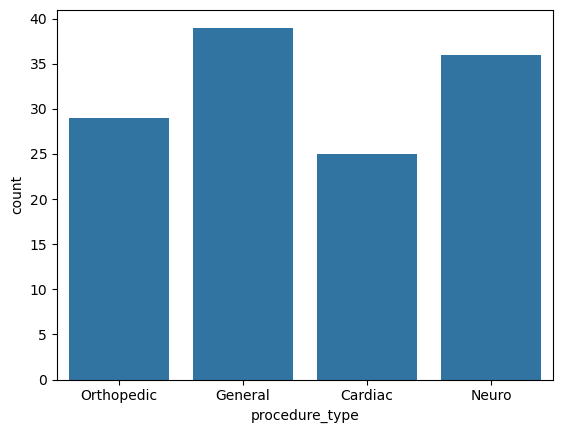

In [22]:
sns.countplot(x= "procedure_type",data=df)
plt.title=("Procedue")
plt.show()

In [17]:
df["emergency_flag"].value_counts(normalize=True)*100

emergency_flag
1    92.248062
0     7.751938
Name: proportion, dtype: float64

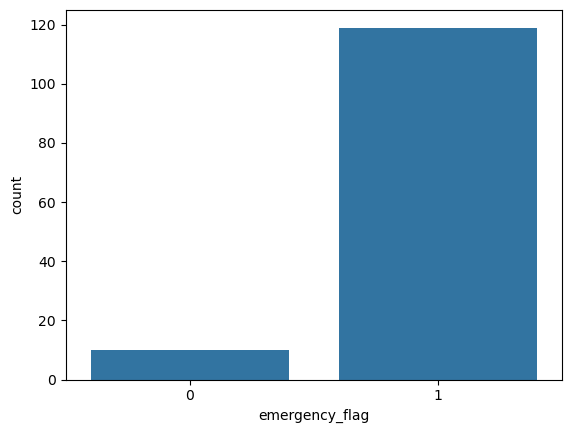

In [ ]:
#how much emergency cases occured
sns.countplot(x="emergency_flag", data=df)
plt.title=("Emergency cases")
plt.show()

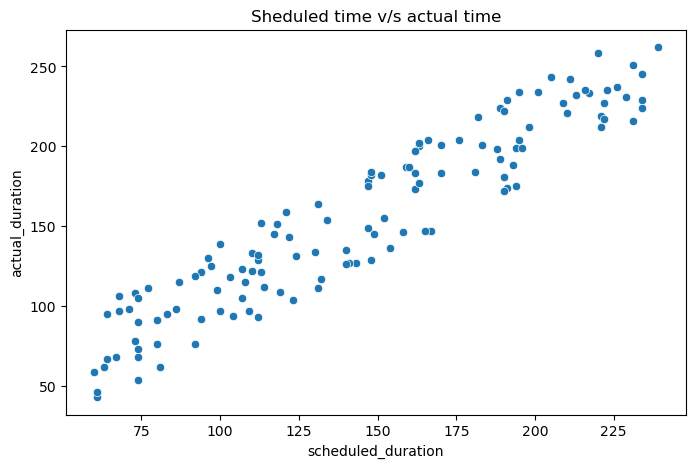

In [20]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="scheduled_duration", 
y="actual_duration",
data=df
)
plt.title("Sheduled time v/s actual time")
plt.show()

In [ ]:
#how many times actual time exceeded
df["overrun"]= (df["actual_duration"] > df["scheduled_duration"]).astype("int")
df["overrun"].value_counts()


overrun
1    87
0    42
Name: count, dtype: int64

In [33]:
#room used
df.groupby("or_room_id")["actual_duration"].sum()

or_room_id
OR1    6711
OR2    5576
OR3    7650
Name: actual_duration, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

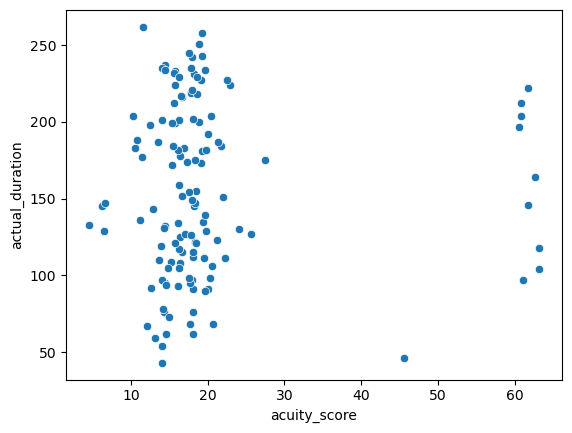

In [37]:
sns.scatterplot(x="acuity_score", y="actual_duration", data=df)
plt.title=("Acuity Score")
plt.show

In [40]:
df["scheduled_start_time"]=pd.to_datetime(df["scheduled_start_time"])
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129 entries, 0 to 128
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   hadm_id               129 non-null    int64         
 1   procedure_type        129 non-null    object        
 2   scheduled_start_time  129 non-null    datetime64[ns]
 3   scheduled_duration    129 non-null    int64         
 4   actual_duration       129 non-null    int64         
 5   emergency_flag        129 non-null    int64         
 6   acuity_score          129 non-null    float64       
 7   or_room_id            129 non-null    object        
 8   surgeon_id            129 non-null    object        
 9   equipment_id          129 non-null    object        
 10  overrun               129 non-null    int32         
dtypes: datetime64[ns](1), float64(1), int32(1), int64(4), object(4)
memory usage: 10.7+ KB


In [43]:
df["overrun"]= (df["actual_duration"] > df["scheduled_duration"]).astype(int)
df["overrun"].value_counts()
df["overrun"].value_counts(normalize=True)*100

overrun
1    67.44186
0    32.55814
Name: proportion, dtype: float64

In [44]:
df.groupby("procedure_type")[["scheduled_duration","actual_duration"]].mean()

,scheduled_duration,actual_duration
procedure_type,,
Cardiac,167.320000,175.640000
General,135.794872,144.743590
Neuro,139.222222,153.194444
Orthopedic,139.482759,151.241379


In [45]:
df.groupby("or_room_id")["actual_duration"].sum()

or_room_id
OR1    6711
OR2    5576
OR3    7650
Name: actual_duration, dtype: int64

In [46]:
df.groupby("emergency_flag")["actual_duration"].mean()

emergency_flag
0    168.000000
1    153.420168
Name: actual_duration, dtype: float64

In [47]:
df.groupby("surgeon_id")["actual_duration"].sum()

surgeon_id
DR1    7192
DR2    6832
DR3    5913
Name: actual_duration, dtype: int64

In [52]:
df.to_csv("projectdataset.csv",index=False)

In [53]:
import pandas as pd
df= pd.read_csv("projectdataset.csv")
df.head()

,hadm_id,procedure_type,scheduled_start_time,scheduled_duration,actual_duration,emergency_flag,acuity_score,or_room_id,surgeon_id,equipment_id,overrun
0,142345,Orthopedic,2025-01-28,162,183,1,16.9,OR2,DR2,EQ3,1
1,105331,General,2025-01-28,239,262,1,11.6,OR2,DR1,EQ1,1
2,165520,Cardiac,2025-01-13,152,155,1,18.5,OR1,DR2,EQ4,1
3,199207,Orthopedic,2025-01-09,74,68,1,17.7,OR3,DR1,EQ4,0
4,177759,Orthopedic,2025-01-29,166,204,1,10.3,OR3,DR1,EQ2,1


In [71]:
y= df["actual_duration"]

In [67]:
x= df[["procedure_type",
    "scheduled_duration",
    "emergency_flag",
    "or_room_id",
    "surgeon_id",
    "equipment_id"]].copy()

In [62]:
from sklearn.preprocessing import LabelEncoder


In [68]:
categorical_cols=["procedure_type",
   "or_room_id",
    "surgeon_id",
    "equipment_id"]
le = LabelEncoder()

for col in categorical_cols:
    x[col] = le.fit_transform(x[col])

In [73]:
#test model
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split( x, y, test_size=0.2, random_state=42) 

In [75]:
#train the model
from sklearn.ensemble import RandomForestRegressor
model= RandomForestRegressor(n_estimators=100,
                            random_state=42)
model.fit(x_train, y_train)

RandomForestRegressor(random_state=42)

In [85]:
#perdict
prediction= model.predict(x_test)

In [86]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, prediction)
rmse = np.sqrt(mean_squared_error(y_test, prediction))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 20.53384615384615
RMSE: 23.82757742939567


In [87]:
df["predicted_duration"] = model.predict(x)


In [88]:
df[["scheduled_duration","actual_duration","predicted_duration"]].head()

,scheduled_duration,actual_duration,predicted_duration
0,162,183,183.53
1,239,262,251.31
2,152,155,159.33
3,74,68,71.29
4,166,204,182.55


In [91]:
df["predicted_overrun"]= model.predict(x)

In [92]:
df["predicted_duration"]=(df["predicted_duration"] > df["scheduled_duration"]).astype(int)


In [93]:
df["predicted_overrun"].value_counts()

predicted_overrun
127.98    2
183.53    1
229.80    1
138.65    1
207.06    1
         ..
218.49    1
143.69    1
115.84    1
160.99    1
94.88     1
Name: count, Length: 128, dtype: int64

In [1]:
from ortools.sat.python import cp_model
print("working!")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\ProgramData\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\ProgramData\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\ProgramData\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "c:\ProgramData\anaconda3\Lib\site-pack

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



ImportError: numpy.core.multiarray failed to import

In [2]:
import numpy as np
print("Numpy:", np.__version__)

from ortools.sat.python import cp_model
print("or-tool working!")

Numpy: 2.4.2


ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject